In [1]:
import pandas as pd, si_units as si, matplotlib.pyplot as plt, numpy as np, feos, sys, json
import TERNARY_CLASS as TC
sys.path.append("..")
import PLOT_SETTINGS as ps
from molmass import Formula

In [2]:
parameters      = feos.Parameters.from_json(["carbon dioxide", "hydrogen", "argon"], "../parameters.json")          
n_total         = 1.0 * si.MOL
CO2_comp        = 0.95
feeds           = TC.generate_feeds(CO2=0.95, n_points=4)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(parameters)

TC.print_array2d(feeds)
parameters

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0167       0.0333
  2 |       0.9500       0.0333       0.0167


|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|

In [3]:
components      = TC.components(parameters)
molar_masses    = [Formula(c).mass for c in components]  # g/mol
T_initial_guess = 200
verbose         = True
P_TOL           = 0.01  # Pressure [bar] tolerance for flash calculations excempting at the saturation points
T_STEP          = 5     # Temperature step for bubble/dew curve calculations (K)
P_STEP          = 5     # Pressure step for flash calculations (bar)
PT_results      = {}
VLE_DFT         = {}


Feed 1: z = [0.95       0.01666667 0.03333333]
Critical Point: T = 305.77 K, P = 90.42 bar
Bubble calculation failed at T = 305 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

Feed 2: z = [0.95       0.03333333 0.01666667]
Critical Point: T = 306.11 K, P = 93.54 bar
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

feed_1:
  T = 200 K: P_bubble = 52.33 bar, P_dew = 2.52 bar
  T = 205 K: P_bubble = 51.16 bar, P_dew = 3.24 bar
  T = 210 K: P_bubble = 50.26 bar, P_dew = 4.11 bar
  T = 215 K: P_bubble = 49.64 bar, P_dew = 5.14 bar
  T = 220 K: P_bubble = 49.29 bar, P_dew = 6.37 bar
  T = 225 K: P_bubble = 49.22 bar, P_dew = 7.80 bar
  T = 230 K: P_bubble = 49.42 bar, P_dew = 9.47 bar
  T = 235 K: P_bubble = 49.91 bar, P_dew = 11.39 bar
  T = 240 K: P_bubble = 50.69 bar, P_dew = 13.59 bar
  T = 245 K: P_bubble = 51.78 bar, P_dew = 16.10 bar
  T = 250 K: P_bubble = 53.19 bar, P_dew = 18.95 b

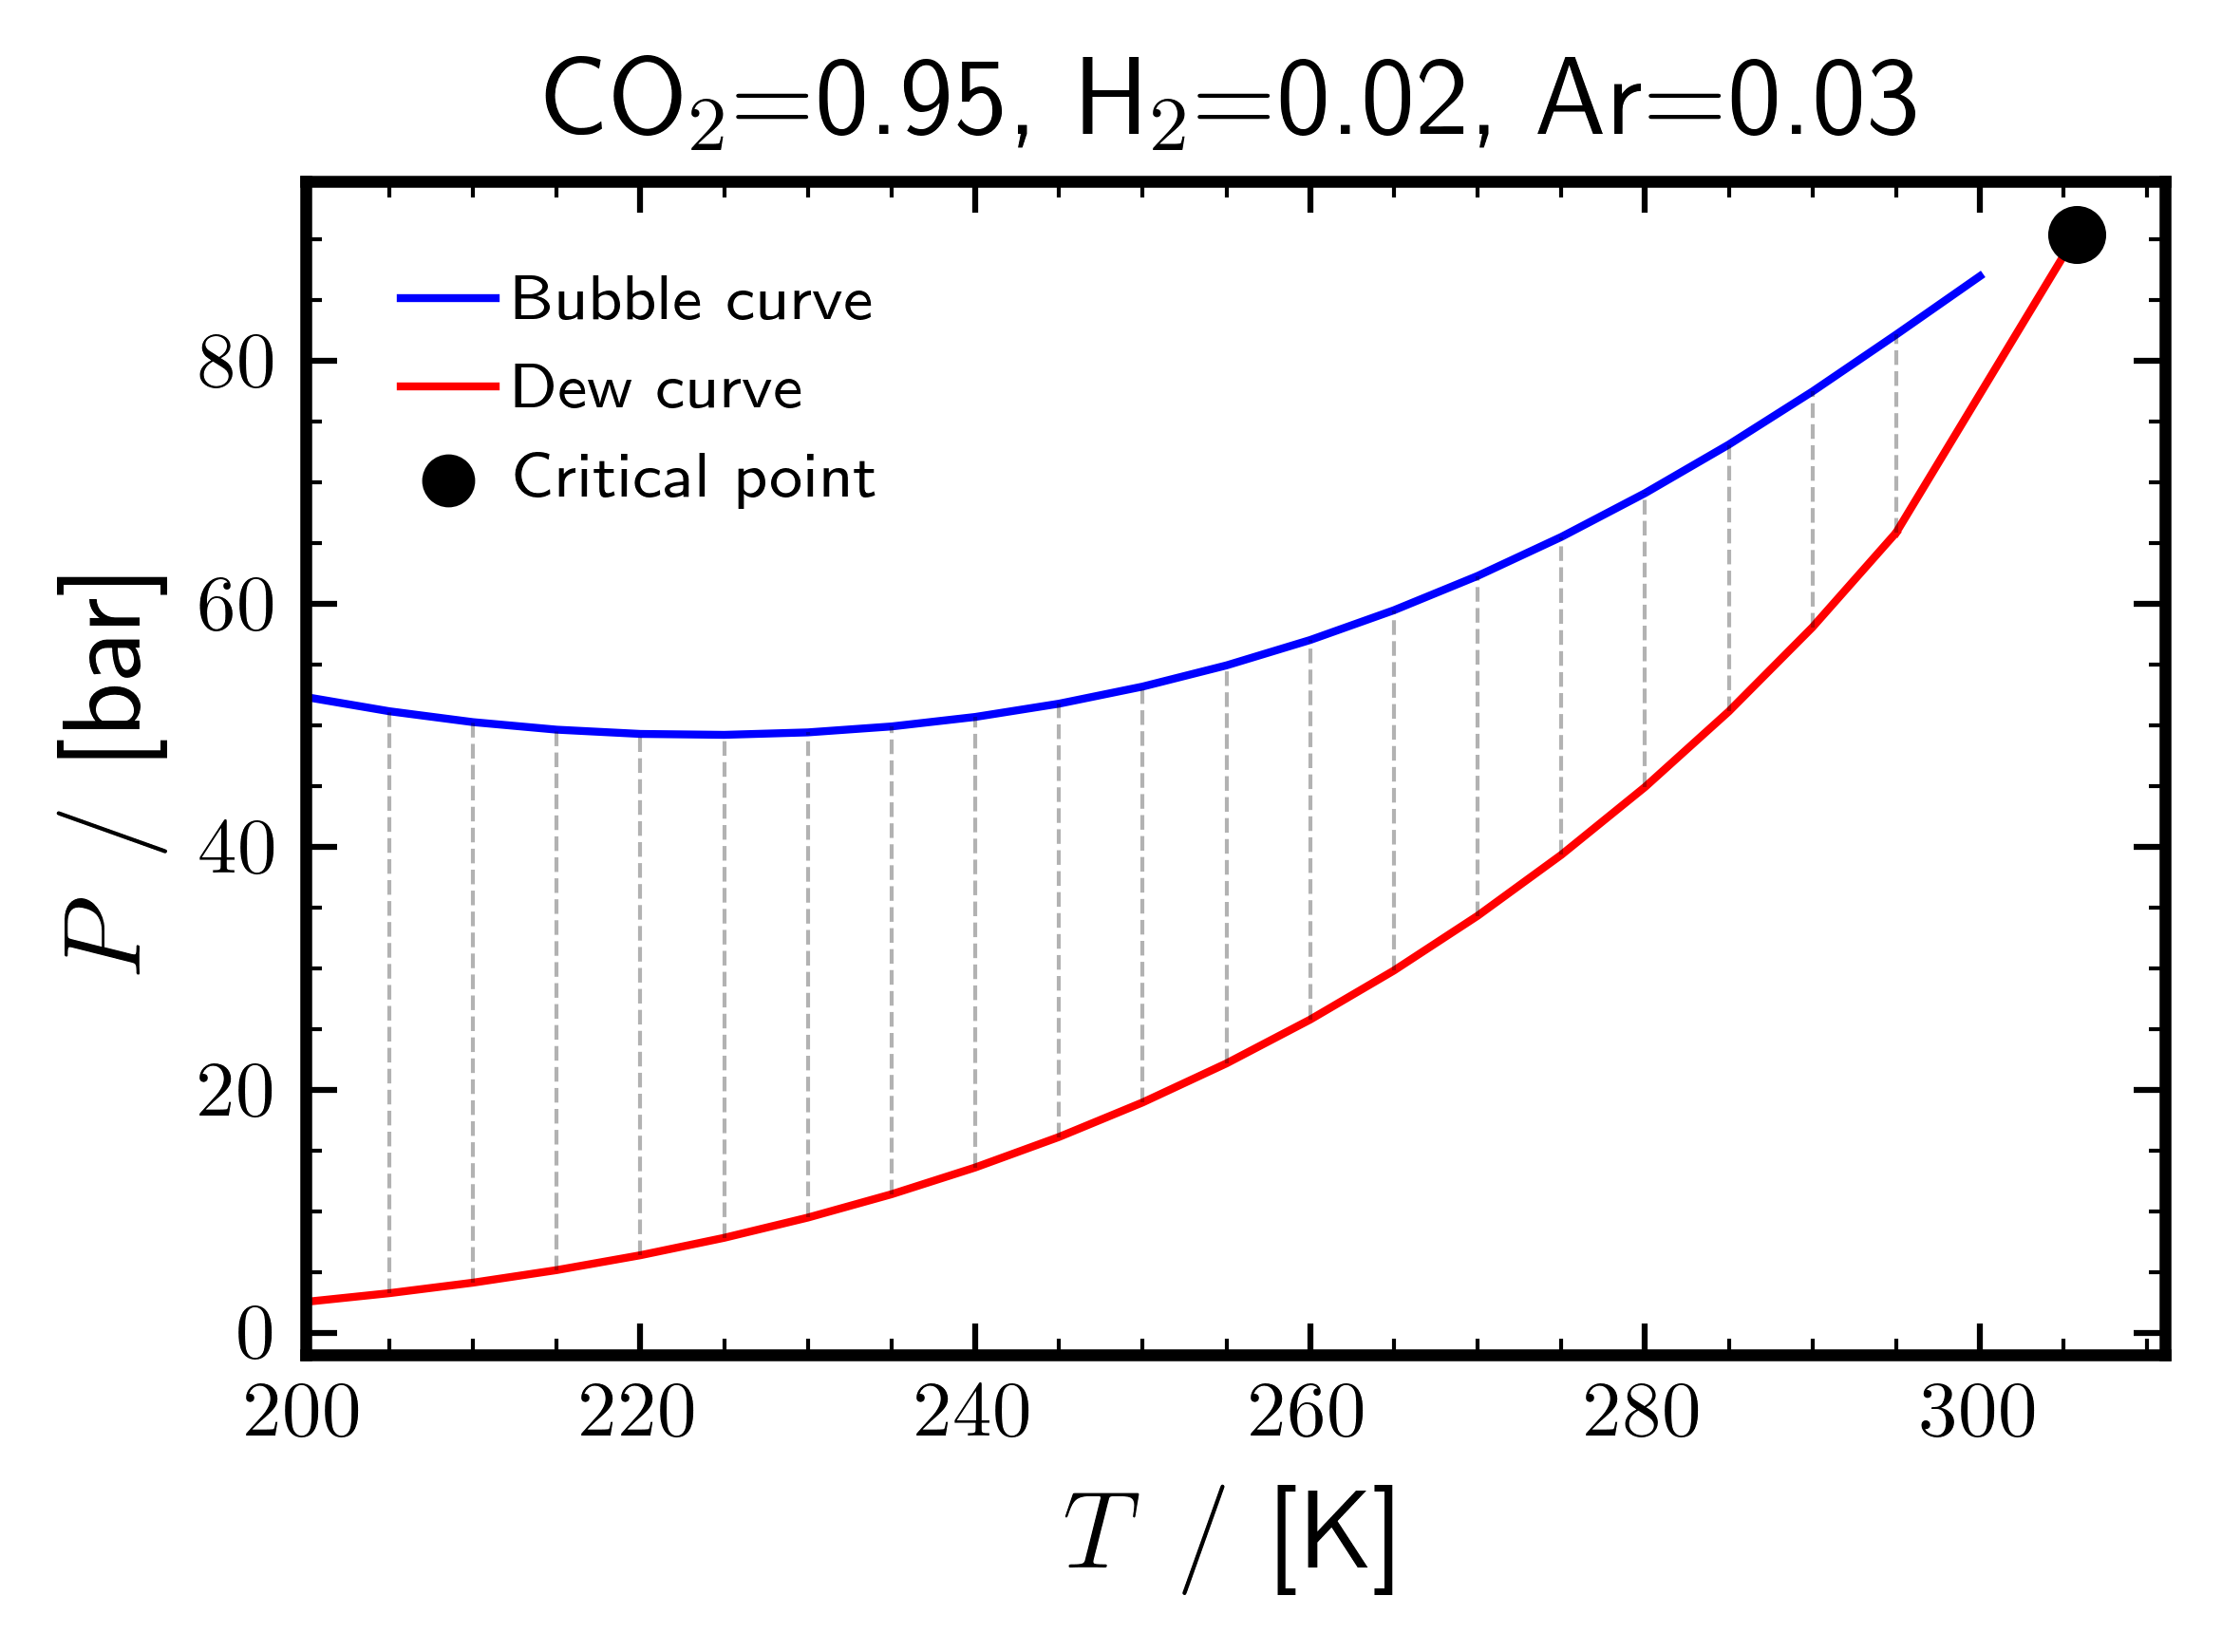

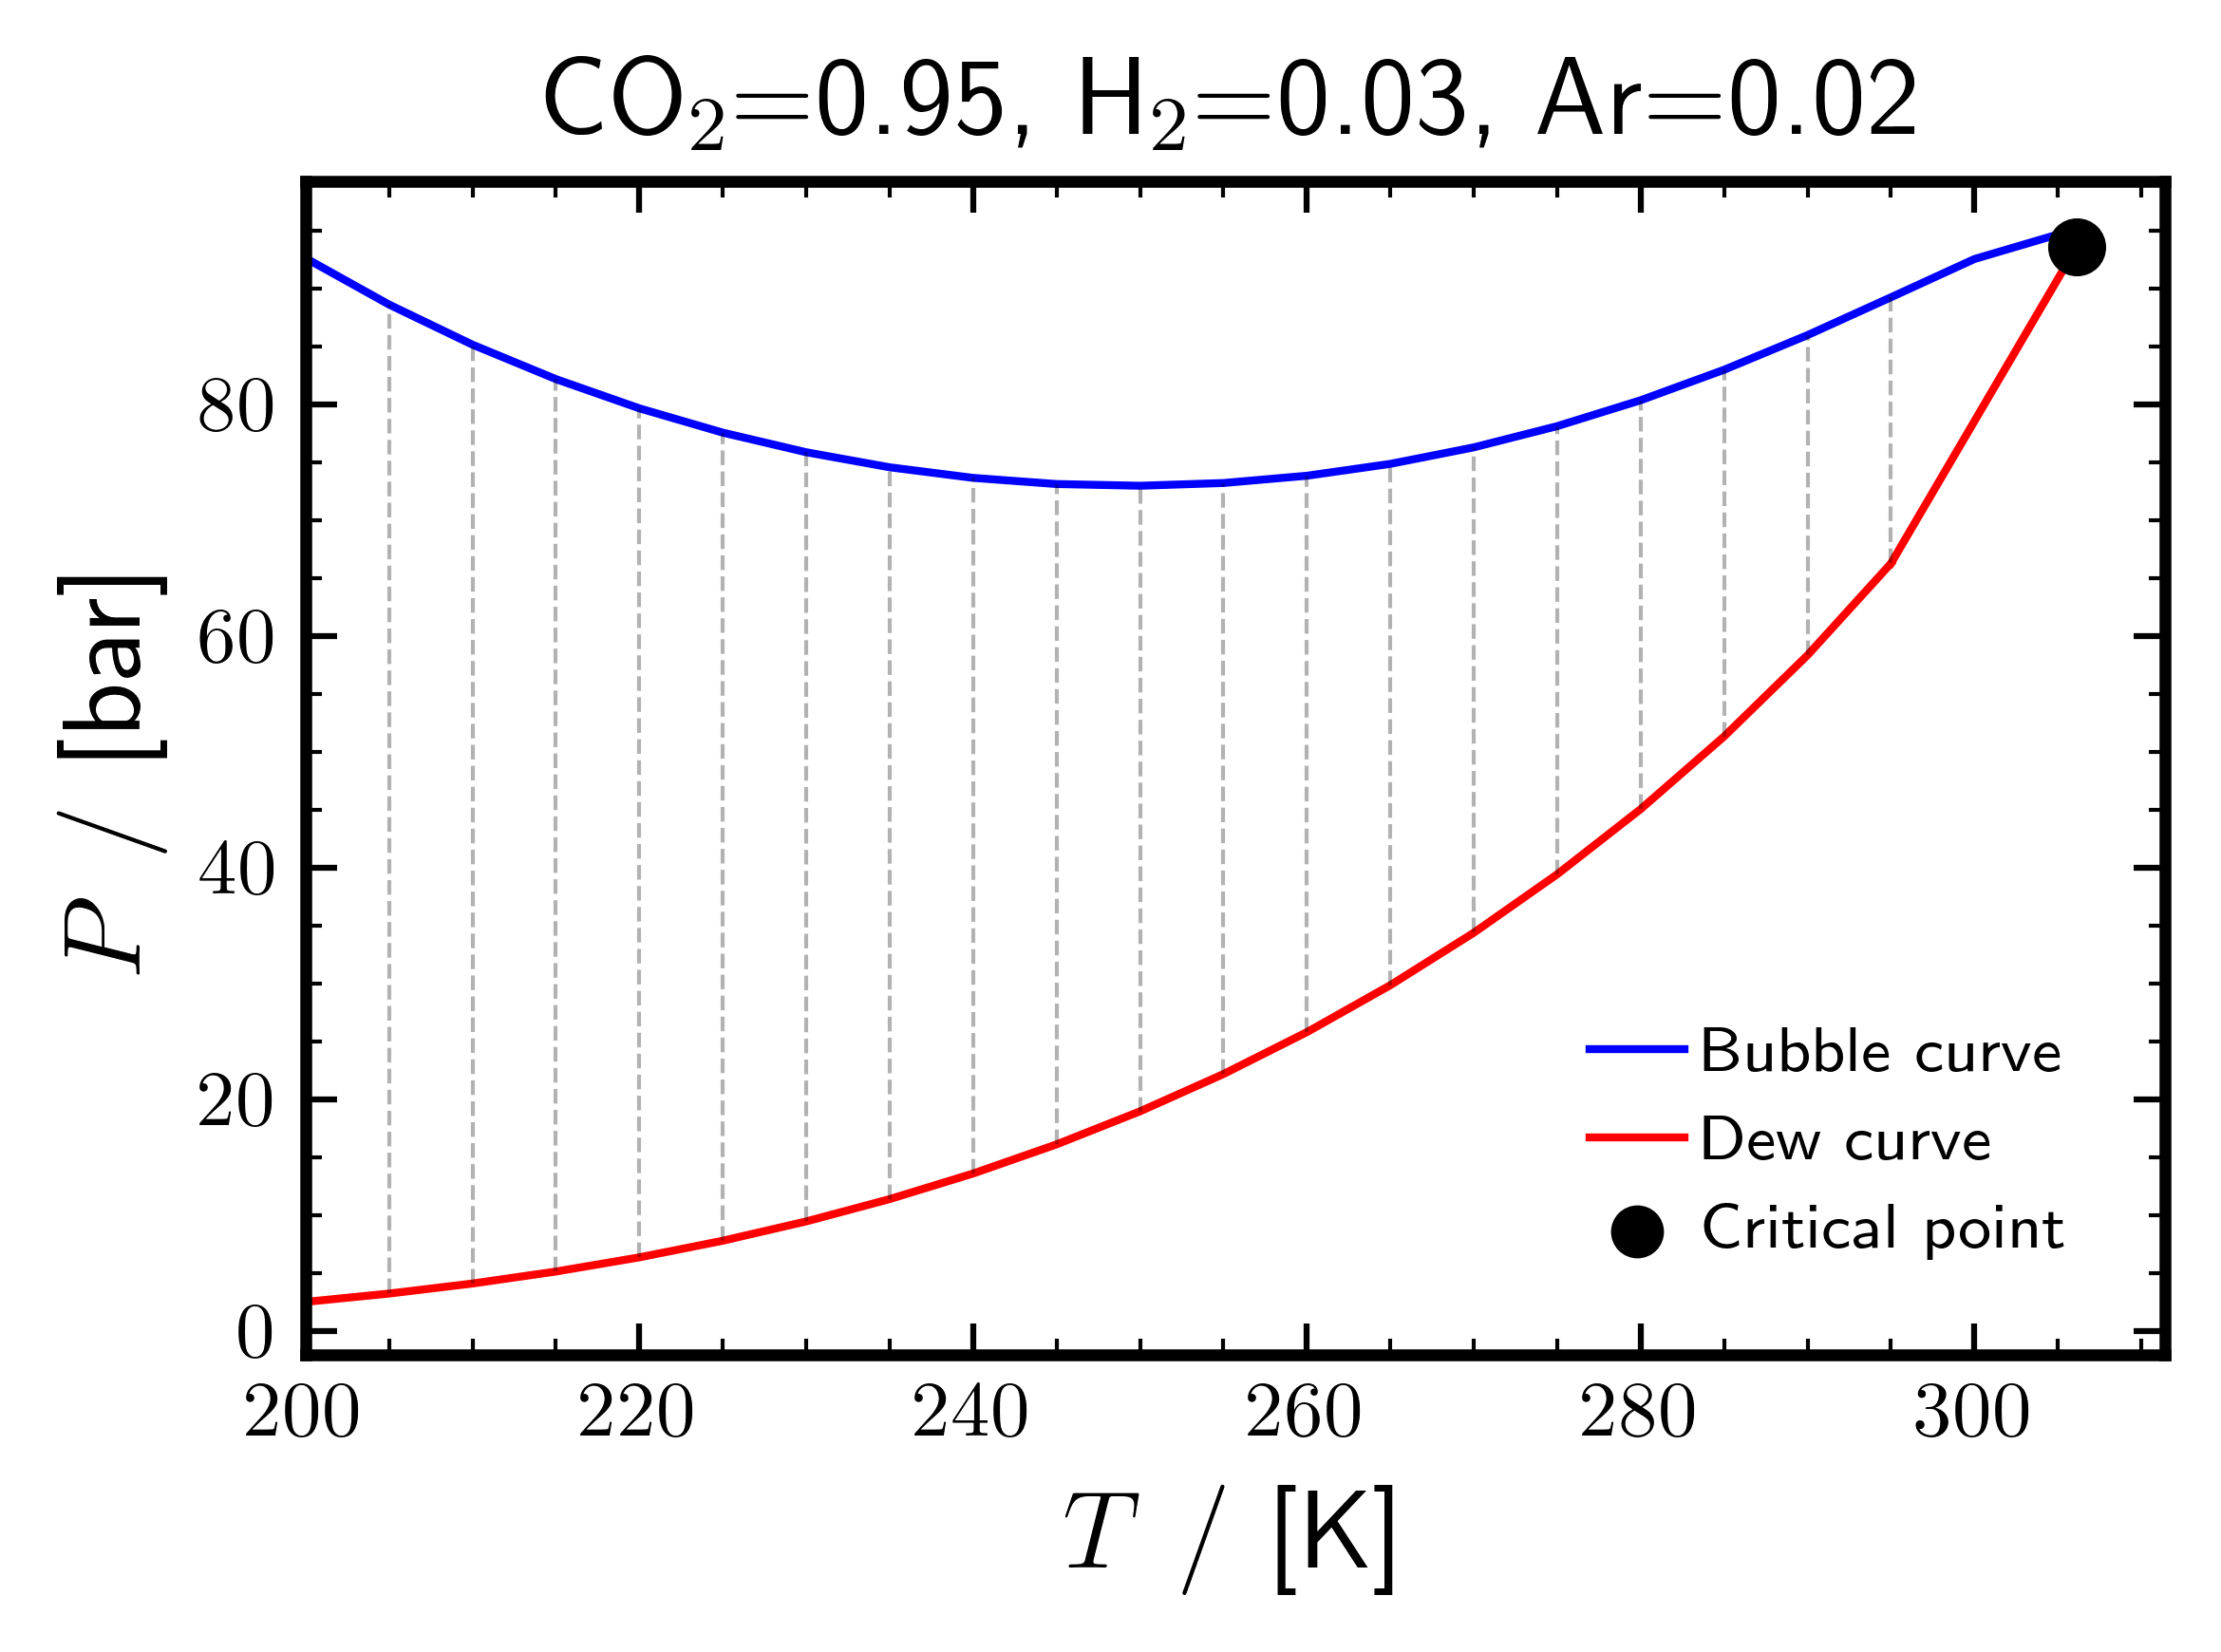

In [4]:
for k, z in enumerate(feeds, start=1):
    
    # --- normalize + mole amounts ---
    z = TC.normalize_z(z)
    feed = TC.compute_feed_moles(z, n_total)
    
    # print(feed)
    if verbose:
        print(f"\nFeed {k}: z = {z}") 
    
    # --- critical point at this composition ---
    CT, CP = TC.compute_CT(feos, eos, z, T_guess=T_initial_guess)
    if verbose:
        print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
    
    # ---- compute bubble and dew curves ----
    T_values                    = range(int(T_initial_guess), int(CT / si.KELVIN) + 1, T_STEP)
    T_bubble, bubble_pressures  = TC.compute_bubble_curve(eos, T_values, feed, verbose=verbose)
    T_dew, dew_pressures        = TC.compute_dew_curve(eos, T_values, feed, verbose=verbose)
    
    # ---- store in dictionary (JSON-safe: convert numpy types to Python floats) ----
    PT_results[f"feed_{k}"] = {
        "z": [round(float(x), 6) for x in np.asarray(z, dtype=float)],
        "TC_K": round(float(CT / si.KELVIN), 2),
        "PC_bar": round(float(CP / si.BAR), 2),
        "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble, bubble_pressures)],
        "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew, dew_pressures)],
    }

# ---- write to file ----
out_file = "PT_Phase_Envelope.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(PT_results, f, indent=2)

######################## PT phase digram spcae sweep , TP flash, and cDFT computations #################

for feed_key, feed in PT_results.items():

    TP_z        = np.array(feed.get("z", []))
    fig, ax     = TC.plot_PT(PT_results, feed_key, parameters)
    
    bub         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    common_T    = sorted(set(bub) & set(dew))

    # ---- Initialize unified storage for this FIXED feed composition ----
    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),  # Fixed feed composition
        "phase_envelope": {
            "bubble_curve": [{"T_K": T, "P_bar": bub[T]} for T in sorted(bub.keys())],
            "dew_curve": [{"T_K": T, "P_bar": dew[T]} for T in sorted(dew.keys())],
            "isothermal_lines": [  # Combined isothermal data
                {"T_K": T, "P_bubble_bar": bub[T], "P_dew_bar": dew[T]} 
                for T in common_T
            ]
        },
        "interfacial_data": {}  # Will be organized by T, then list of P values
    }
    
    if verbose:
        print(f"\n{feed_key}:")
        for T in common_T:
            print(f"  T = {T} K: P_bubble = {bub[T]:.2f} bar, P_dew = {dew[T]:.2f} bar")
    
    if common_T:
        for T in common_T:
            
            P_b = bub[T]
            P_d = dew[T]

            if P_b >= P_d:
                
                pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, 10)
                
                # ---- optional: PLOT ----
                ax.plot([T, T], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)
                
                # Initialize list for this temperature
                VLE_DFT[feed_key]["interfacial_data"][T] = []
                
                for P in pressures:
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} | z = {TP_z}")
                       
                    # --- TP flash ---
                    try:
                        eq, x, y, liquid_density, vapor_density = TC.tp_flash(
                            feos, eos, T*si.KELVIN, P*si.BAR, TP_z*si.MOL, molar_masses)
                    except Exception as e:
                        print(f"TP flash failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        continue
                    
                    # --- planar interface & surface tension ---
                    interface = TC.build_planar_interface(
                        eq, critical_temperature=CT, n_grid=500, l_grid=100.0)
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, (E_1, E_2, E_3) = \
                            TC.solve_interface_properties(interface, si)
                    except Exception as e:
                        print(f"Surface tension calculation failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        E_1, E_2, E_3 = np.nan, np.nan, np.nan
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

                    # ---- Use TC.row_append for consistent formatting ----
                    row_data = TC.row_append(
                        x, y, liquid_density, vapor_density, 
                        CT, gamma_mN_m, interfacial_thickness_nm, 
                        components, (E_1, E_2, E_3))
                    
                    # Add T and P to the row
                    row_data["T_K"] = float(T)
                    row_data["P_bar"] = float(P)
                    
                    # Store in interfacial_data
                    VLE_DFT[feed_key]["interfacial_data"][T].append(row_data)
                    
    ps.save_plot(fig, f"PT_{feed_key}")

In [5]:
# --- Storing the data as CSV files --- #
import pandas as pd

for feed_key in VLE_DFT:
    
    # Get all interfacial data across all temperatures
    all_data = []
    for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
        all_data.extend(data_list)  # Each item already has T_K and P_bar from TC.row_append
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Save to CSV
    csv_filename = f"{feed_key}_interfacial_results.csv"
    df.to_csv(csv_filename, index=False)
    print(f"Saved {len(df)} rows to {csv_filename}")
    
    # Optional: Also save phase envelope data separately
    envelope_data = {
        "bubble_curve": pd.DataFrame(VLE_DFT[feed_key]["phase_envelope"]["bubble_curve"]),
        "dew_curve": pd.DataFrame(VLE_DFT[feed_key]["phase_envelope"]["dew_curve"]),
        "isothermal_lines": pd.DataFrame(VLE_DFT[feed_key]["phase_envelope"]["isothermal_lines"])
    }
    
    # Save envelope as separate CSV or combined
    envelope_filename = f"{feed_key}_phase_envelope.csv"
    pd.DataFrame(VLE_DFT[feed_key]["phase_envelope"]["isothermal_lines"]).to_csv(
        envelope_filename, index=False
    )

Saved 200 rows to feed_1_interfacial_results.csv
Saved 200 rows to feed_2_interfacial_results.csv


In [ ]:
# TP_z = np.array([0.95, 0.01, 0.04])
# try:
#     eq, x, y, liquid_density, vapor_density = TC.tp_flash(feos, eos, 220*si.KELVIN, 20*si.BAR, TP_z*si.MOL, molar_masses)
# except Exception as e:
#     print(f"TP flash failed for z = {TP_z}: {e}")            

In [ ]:
# Quick TEST
print("Available feeds:", list(VLE_DFT.keys()))
for feed_key in VLE_DFT:
    n_bubble = len(VLE_DFT[feed_key]["phase_envelope"]["bubble_curve"])
    n_dew = len(VLE_DFT[feed_key]["phase_envelope"]["dew_curve"])
    n_temps = len(VLE_DFT[feed_key]["interfacial_data"])
    print(f"{feed_key}: {n_bubble} bubble pts, {n_dew} dew pts, {n_temps} isotherms")

Available feeds: ['feed_1', 'feed_2']
feed_1: 21 bubble pts, 20 dew pts, 20 isotherms
feed_2: 22 bubble pts, 20 dew pts, 20 isotherms



Processing feed_1:
  Data points: 195
  T range: 200.0 - 295.0 K
  P range: 2.53 - 82.16 bar
  Gamma range: 0.5989 - 19.8796 mN/m
  Valid interpolated points: 5498/10000
  Masked gamma range: 0.5989 - 19.5080 mN/m
  Successfully created interpolated color map
  Saved: feed_1_PT_diagram_gamma.png



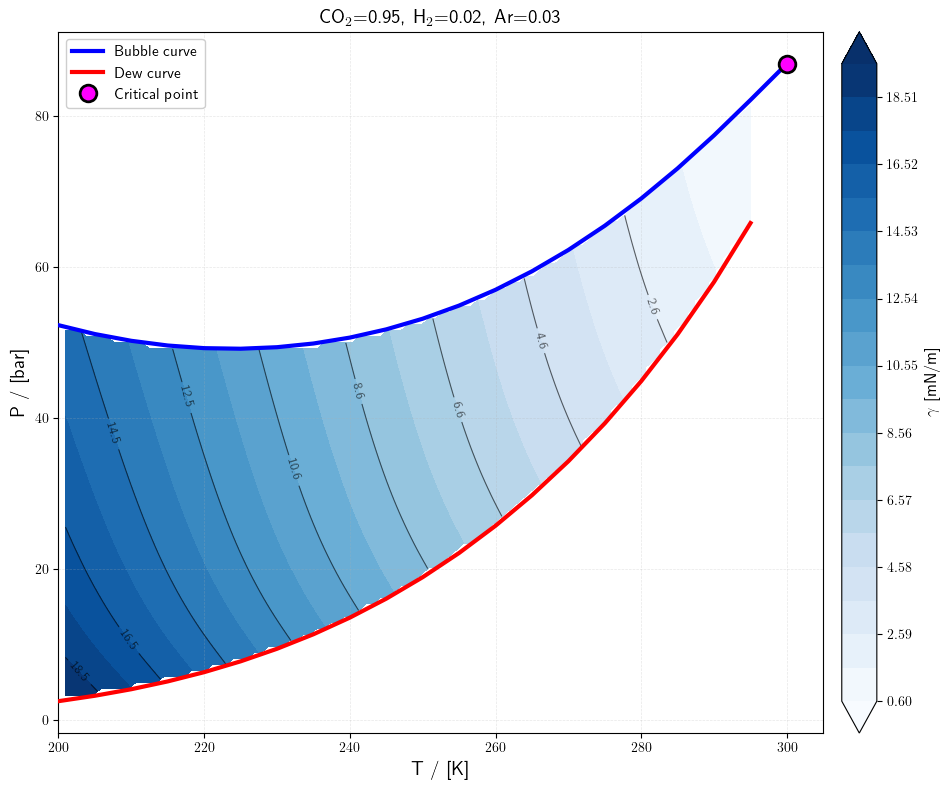


Processing feed_2:
  Data points: 187
  T range: 200.0 - 295.0 K
  P range: 2.53 - 92.59 bar
  Gamma range: 0.8329 - 19.8916 mN/m
  Valid interpolated points: 7219/10000
  Masked gamma range: 0.8379 - 19.5691 mN/m
  Successfully created interpolated color map
  Saved: feed_2_PT_diagram_gamma.png



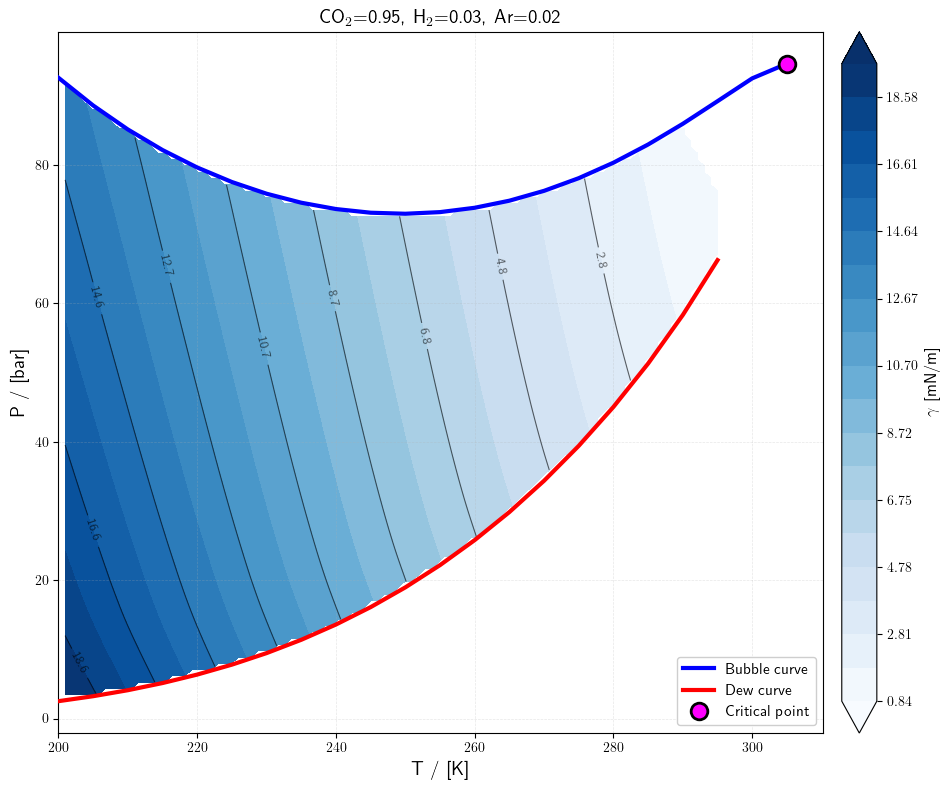


All plots completed!


In [40]:
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

for feed_key in VLE_DFT:
    
    # Get phase envelope data
    bubble_data = VLE_DFT[feed_key]["phase_envelope"]["bubble_curve"]
    dew_data = VLE_DFT[feed_key]["phase_envelope"]["dew_curve"]
    
    # CHECK 1: Make sure these lists are not empty
    if not bubble_data or not dew_data:
        print(f"Warning: {feed_key} has empty bubble or dew data")
        continue
    
    # Extract T, P for bubble and dew curves
    T_bubble = [pt["T_K"] for pt in bubble_data]
    P_bubble = [pt["P_bar"] for pt in bubble_data]
    T_dew = [pt["T_K"] for pt in dew_data]
    P_dew = [pt["P_bar"] for pt in dew_data]
    
    # Collect all interfacial tension data with T, P coordinates
    gamma_data = []
    T_gamma = []
    P_gamma = []
    
    for T_K, data_list in VLE_DFT[feed_key]["interfacial_data"].items():
        for point in data_list:
            if "gamma_mN_m" in point and not np.isnan(point["gamma_mN_m"]):
                T_gamma.append(point["T_K"])
                P_gamma.append(point["P_bar"])
                gamma_data.append(point["gamma_mN_m"])
    
    # Check if we have enough data
    if len(gamma_data) < 4:
        print(f"Warning: {feed_key} has insufficient interfacial tension data ({len(gamma_data)} points)")
        continue
    
    print(f"\nProcessing {feed_key}:")
    print(f"  Data points: {len(gamma_data)}")
    print(f"  T range: {min(T_gamma):.1f} - {max(T_gamma):.1f} K")
    print(f"  P range: {min(P_gamma):.2f} - {max(P_gamma):.2f} bar")
    print(f"  Gamma range: {min(gamma_data):.4f} - {max(gamma_data):.4f} mN/m")
    
    # Create figure with white background
    fig1, ax1 = plt.subplots(figsize=(10, 8), facecolor='white')
    ax1.set_facecolor('white')
    
    # Create grid for interpolation
    use_scatter = False  # Flag to determine plot type
    
    try:
        T_grid = np.linspace(min(T_gamma), max(T_gamma), 100)
        P_grid = np.linspace(min(P_gamma), max(P_gamma), 100)
        T_mesh, P_mesh = np.meshgrid(T_grid, P_grid)
        
        # Try cubic first, fall back to linear if it fails
        try:
            gamma_mesh = griddata((T_gamma, P_gamma), gamma_data, (T_mesh, P_mesh), 
                                 method='cubic', fill_value=np.nan)
        except:
            print(f"  Cubic interpolation failed, using linear")
            gamma_mesh = griddata((T_gamma, P_gamma), gamma_data, (T_mesh, P_mesh), 
                                 method='linear', fill_value=np.nan)
        
        # Diagnostic: Check interpolation quality
        n_valid = np.sum(~np.isnan(gamma_mesh))
        print(f"  Valid interpolated points: {n_valid}/{gamma_mesh.size}")
        
        # Check if interpolation produced valid data
        if np.all(np.isnan(gamma_mesh)) or n_valid < 10:
            print(f"  Insufficient valid interpolation, using scatter plot")
            use_scatter = True
        else:
            # Get valid range for colorbar
            gamma_min = np.nanmin(gamma_mesh)
            gamma_max = np.nanmax(gamma_mesh)
            
            # Check for valid range
            if np.isnan(gamma_min) or np.isnan(gamma_max) or gamma_min == gamma_max:
                print(f"  Invalid gamma range, using scatter plot")
                use_scatter = True
            else:
                # ============================================
                # MASK DATA OUTSIDE PHASE ENVELOPE
                # ============================================
                # Create path from phase envelope (bubble + dew curves)
                envelope_T = T_bubble + T_dew[::-1]
                envelope_P = P_bubble + P_dew[::-1]
                
                envelope_path = Path(np.column_stack([envelope_T, envelope_P]))
                
                # Check which grid points are inside the envelope
                grid_points = np.column_stack([T_mesh.ravel(), P_mesh.ravel()])
                inside_envelope = envelope_path.contains_points(grid_points)
                inside_envelope = inside_envelope.reshape(T_mesh.shape)
                
                # Mask values outside the envelope
                gamma_mesh_masked = np.where(inside_envelope, gamma_mesh, np.nan)
                
                # Update gamma_min and gamma_max based on masked data
                gamma_min = np.nanmin(gamma_mesh_masked)
                gamma_max = np.nanmax(gamma_mesh_masked)
                
                print(f"  Masked gamma range: {gamma_min:.4f} - {gamma_max:.4f} mN/m")
                
                # Mask NaN values
                gamma_masked = np.ma.masked_invalid(gamma_mesh_masked)
                
                # ============================================
                # PLOT WITH SEQUENTIAL COLORMAP
                # ============================================
                # Choose sequential colormap: 'Blues', 'RdPu', 'YlGnBu', 'PuBu', 'BuPu'
                cmap = plt.cm.Blues  # Light to dark blue like your reference
                
                # Create discrete levels for smoother appearance
                levels = np.linspace(gamma_min, gamma_max, 20)
                
                try:
                    # Use contourf for filled contours
                    contour = ax1.contourf(T_mesh, P_mesh, gamma_masked,
                                          levels=levels,
                                          cmap=cmap,
                                          extend='both')
                    
                    cbar = fig1.colorbar(contour, ax=ax1, pad=0.02)
                    cbar.set_label(r'$\gamma$ [mN/m]', fontsize=12)
                    
                    # Add black contour lines like in reference
                    contour_lines = ax1.contour(T_mesh, P_mesh, gamma_masked,
                                                levels=levels[::2],  # Every other level
                                                colors='black',
                                                linewidths=0.8,
                                                alpha=0.6)
                    
                    # Add contour labels
                    ax1.clabel(contour_lines, inline=True, fontsize=9, fmt='%.1f')
                    
                    print(f"  Successfully created interpolated color map")
                    
                except Exception as e_contourf:
                    print(f"  contourf failed: {e_contourf}, trying pcolormesh")
                    # Fallback to pcolormesh
                    mesh = ax1.pcolormesh(T_mesh, P_mesh, gamma_masked,
                                         cmap=cmap,
                                         shading='auto',
                                         vmin=gamma_min,
                                         vmax=gamma_max)
                    
                    cbar = fig1.colorbar(mesh, ax=ax1, pad=0.02)
                    cbar.set_label(r'$\gamma$ [mN/m]', fontsize=12)
        
    except Exception as e:
        print(f"  Interpolation failed: {e}, using scatter plot")
        use_scatter = True
    
    # Fallback to scatter plot if needed
    if use_scatter and len(gamma_data) > 0:
        print(f"  Using scatter plot for {feed_key}")
        norm = Normalize(vmin=min(gamma_data), vmax=max(gamma_data))
        scatter = ax1.scatter(T_gamma, P_gamma, c=gamma_data, cmap=plt.cm.Blues, 
                           s=100, norm=norm, edgecolors='black', linewidth=0.5,
                           zorder=5, alpha=0.8)
        
        cbar = fig1.colorbar(scatter, ax=ax1, pad=0.02)
        cbar.set_label(r'$\gamma$ [mN/m]', fontsize=12)
    
    # Plot bubble and dew curves on top with thicker lines
    ax1.plot(T_bubble, P_bubble, 'b-', linewidth=3, label='Bubble curve', zorder=10)
    ax1.plot(T_dew, P_dew, 'r-', linewidth=3, label='Dew curve', zorder=10)
    
    # Critical point
    if T_bubble and P_bubble:
        ax1.plot(T_bubble[-1], P_bubble[-1], 'ko', markersize=12, 
                markerfacecolor='magenta', markeredgewidth=2,
                label='Critical point', zorder=15)
    
    # Labels and formatting
    z = VLE_DFT[feed_key]["z"]
    ax1.set_xlabel('T / [K]', fontsize=14)
    ax1.set_ylabel('P / [bar]', fontsize=14)
    ax1.set_title(f'CO$_2$={z[0]:.2f}, H$_2$={z[1]:.2f}, Ar={z[2]:.2f}', fontsize=14)
    ax1.legend(fontsize=11, loc='best', framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Save and show
    output_filename = f'{feed_key}_PT_diagram_gamma.png'
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"  Saved: {output_filename}\n")
    plt.show()
    plt.close(fig1)

print("\nAll plots completed!")